<a href="https://colab.research.google.com/github/somonox/The-Three-body-Problem/blob/main/three_body.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using", device)


using cuda


In [ ]:
class ThreeBodyPINN(nn.Module):
    def __init__(self, hidden_dim=64, num_hidden_layers=3):
        super().__init__()

        input_dim = 1   # t 하나
        output_dim = 9  # 3개 물체 * 3차원 = 9

        layers = [nn.Linear(input_dim, hidden_dim), nn.Tanh()]

        for _ in range(num_hidden_layers):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())

        layers.append(nn.Linear(hidden_dim, output_dim))

        self.net = nn.Sequential(*layers)

    def forward(self, t):
        """
        t: shape (batch_size, 1)
        return: shape (batch_size, 9)
                = [x1,y1,z1,x2,y2,z2,x3,y3,z3]
        """
        return self.net(t)


In [ ]:
def split_positions(y):
    """
    y: (batch_size, 9)
       = [x1,y1,z1,x2,y2,z2,x3,y3,z3]
    return: positions: (batch_size, 3, 3)
            positions[:, 0, :] = (x1,y1,z1)
            positions[:, 1, :] = (x2,y2,z2)
            positions[:, 2, :] = (x3,y3,z3)
    """
    batch_size = y.shape[0]
    return y.view(batch_size, 3, 3)


In [ ]:
def time_derivatives(model, t):
    """
    model: ThreeBodyPINN
    t: (batch_size, 1), requires_grad=True 이어야 함
    return:
        pos: (batch_size, 9)
        vel: (batch_size, 9)
        acc: (batch_size, 9)
    """
    # 0. 위치 예측
    pos = model(t) # (batch_size, 9)

    # 1. 속도 예측 (pos를 t에 대해 1차 미분)
    # Each of the 9 position components (x1,y1,z1,...) needs its derivative w.r.t. time (t)
    # We need to compute d(pos[b, k])/d(t[b, 0]) for each batch element 'b' and each coordinate 'k'.
    # torch.autograd.grad with grad_outputs=ones_like(pos) would sum gradients across output dimensions,
    # leading to a (batch_size, 1) result if inputs are (batch_size, 1). Here, we need a (batch_size, 9) result.

    vel_list = []
    for i in range(pos.shape[1]): # Iterate over the 9 output dimensions (x1, y1, z1, x2, ...)
        # Compute gradient of pos[:, i] (a (batch_size,) tensor) with respect to t (a (batch_size, 1) tensor).
        # This will correctly return a (batch_size, 1) tensor for each component.
        grad_single_output = torch.autograd.grad(
            outputs=pos[:, i], # Select one column, resulting in a (batch_size,) tensor
            inputs=t,
            grad_outputs=torch.ones_like(pos[:, i]), # grad_outputs for this single column
            create_graph=True,
            retain_graph=True
        )[0] # The result will be (batch_size, 1)
        vel_list.append(grad_single_output)

    vel = torch.cat(vel_list, dim=1) # Concatenate the 9 (batch_size, 1) tensors to form (batch_size, 9)

    # 2. 가속도 예측 (vel를 t에 대해 1차 미분 = pos를 t에 대해 2차 미분)
    # Similar logic for acceleration from velocity.
    acc_list = []
    for i in range(vel.shape[1]):
        grad_single_output = torch.autograd.grad(
            outputs=vel[:, i],
            inputs=t,
            grad_outputs=torch.ones_like(vel[:, i]),
            create_graph=True,
            retain_graph=True
        )[0]
        acc_list.append(grad_single_output)

    acc = torch.cat(acc_list, dim=1) # (batch_size, 9)

    return pos, vel, acc

In [ ]:
def gravitational_acceleration(positions, masses, G=1.0, eps=1e-6):
    """
    positions: (batch_size, 3, 3)
               positions[:, i, :] = i번 물체 (x,y,z)
    masses:    (3,)  -> [m1, m2, m3]
    G:         스칼라, 중력상수
    eps:       0으로 나누기 방지용 작은 수
    return:
        accel: (batch_size, 3, 3)
               accel[:, i, :] = i번 물체 가속도 (ax,ay,az)
    """
    batch_size, num_bodies, _ = positions.shape # num_bodies = 3

    # Calculate relative position vectors r_j - r_i for all pairs (i, j)
    # rij_vectors[b, i, j, :] will be positions[b, j, :] - positions[b, i, :]
    rij_vectors = positions.unsqueeze(1) - positions.unsqueeze(2) # (batch_size, num_bodies, num_bodies, 3)

    # Calculate distances ||r_j - r_i||
    # r[b, i, j] is the distance between body i and body j
    r = torch.linalg.norm(rij_vectors, dim=-1) # (batch_size, num_bodies, num_bodies)

    # Mask out self-interaction (r=0 when i==j) and prevent division by zero
    # By setting r to 1 where r is 0, these terms will be removed by the mask later.
    r_masked = torch.where(r == 0, torch.ones_like(r), r)

    # Calculate r^3 + epsilon
    r3 = r_masked**3 + eps # (batch_size, num_bodies, num_bodies)

    # Expand masses for broadcasting. masses_expanded[0, 0, j, 0] = masses[j]
    # This allows multiplying each rij_vector by the mass of the 'source' body j
    masses_expanded = masses.view(1, 1, num_bodies, 1)

    # Calculate the acceleration term G * m_j * (r_j - r_i) / ||r_j - r_i||^3
    # The unsqueeze(-1) on r3 makes it (batch_size, num_bodies, num_bodies, 1) for division
    term = masses_expanded * rij_vectors / r3.unsqueeze(-1) # (batch_size, num_bodies, num_bodies, 3)

    # Create a mask to exclude self-interaction terms (i == j)
    # The mask will be (1, num_bodies, num_bodies, 1)
    mask = (1 - torch.eye(num_bodies, device=positions.device)).bool().view(1, num_bodies, num_bodies, 1)

    # Apply the mask and sum contributions from all other bodies (j) for each body (i)
    # total_accel[b, i, :] is the total acceleration of body i
    total_accel = G * torch.sum(term * mask, dim=2) # (batch_size, num_bodies, 3)

    return total_accel

In [ ]:
def physics_loss(model, t_colloc, masses, G=1.0):
    """
    model: ThreeBodyPINN
    t_colloc: (batch_size, 1)  -> collocation points {t_k}
    masses: (3,)
    """
    # t_colloc 에 gradient 필요
    t_colloc = t_colloc.clone().detach().requires_grad_(True)

    # pos_pred: (batch, 9), acc_pred: (batch, 9)
    pos_pred, vel_pred, acc_pred = time_derivatives(model, t_colloc)

    # (batch, 9) -> (batch,3,3)
    positions = split_positions(pos_pred)
    acc_pred_reshaped = split_positions(acc_pred)  # (batch,3,3)

    # 뉴턴식으로 계산한 가속도
    acc_phys = gravitational_acceleration(positions, masses, G=G)

    # 잔차 R = a_pred - a_phys
    residual = acc_pred_reshaped - acc_phys  # (batch,3,3)

    # 잔차 제곱 평균 = 물리 손실
    loss = torch.mean(residual**2)
    return loss


In [ ]:
def initial_condition_loss(model, t0, r0, v0):
    """
    model: ThreeBodyPINN
    t0: (1,1), 값은 0.0
    r0: (3,3) -> 초기 위치 [[x1,y1,z1],[x2,y2,z2],[x3,y3,z3]]
    v0: (3,3) -> 초기 속도 [[vx1,vy1,vz1],...]
    """
    t0 = t0.clone().detach().requires_grad_(True)

    # pos(0), vel(0), acc(0) 모두 얻기
    pos0_flat, vel0_flat, _ = time_derivatives(model, t0)  # 각 (1,9)

    pos0 = split_positions(pos0_flat)[0]  # (3,3)
    vel0 = split_positions(vel0_flat)[0]  # (3,3)

    # 위치 차이
    pos_diff = pos0 - r0  # (3,3)
    pos_loss = torch.mean(pos_diff**2)

    # 속도 차이
    vel_diff = vel0 - v0  # (3,3)
    vel_loss = torch.mean(vel_diff**2)

    return pos_loss + vel_loss


In [ ]:
# 1) 모델, 옵티마이저, 상수들 설정
model = ThreeBodyPINN(hidden_dim=64, num_hidden_layers=3).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

# 질량들 (예: 모두 1)
masses = torch.tensor([1.0, 1.0, 1.0], dtype=torch.float32, device=device)

# 중력상수 (단위계 스케일링해서 1로 놓아도 됨)
G = 1.0

r0 = torch.tensor(
    [
        [ 1.0, 0.0, 0.0],
        [-1.0, 0.0, 0.0],
        [ 0.0, 1.0, 0.0],
    ], dtype=torch.float32, device=device)

v0 = torch.tensor(
    [
        [ 0.0, 0.5, 0.0],
        [ 0.0,-0.5, 0.0],
        [ 0.5, 0.0, 0.0],
    ], dtype=torch.float32, device=device)

t0 = torch.tensor([[0.0]], dtype=torch.float32, device=device)

lambda_phys = 5.0
lambda_IC   = 2.0

# 2) 학습 루프
num_epochs = 2000
batch_size = 32
T = 5.0  # 시간 범위 [0, T]

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    # collocation points: [0, T] 구간에서 랜덤 시간 샘플
    t_colloc = (torch.rand(batch_size, 1, device=device) * T)


    # 물리 손실
    L_phys = physics_loss(model, t_colloc, masses, G=G)

    # 초기조건 손실
    L_IC = initial_condition_loss(model, t0, r0, v0)

    # 총 손실
    loss = lambda_phys * L_phys + lambda_IC * L_IC

    # 역전파 & 경사하강
    loss.backward()
    optimizer.step()

    if epoch % 200 == 0:
        print(f"[epoch {epoch}] loss = {loss.item():.6f}, "
              f"L_phys = {L_phys.item():.6f}, L_IC = {L_IC.item():.6f}")

[epoch 0] loss = 2371.844482, L_phys = 474.212616, L_IC = 0.390706
[epoch 200] loss = 1.551554, L_phys = 0.153488, L_IC = 0.392058
[epoch 400] loss = 1.155390, L_phys = 0.075223, L_IC = 0.389637
[epoch 600] loss = 1.008765, L_phys = 0.057602, L_IC = 0.360377
[epoch 800] loss = 0.846076, L_phys = 0.044381, L_IC = 0.312086
[epoch 1000] loss = 0.693699, L_phys = 0.035990, L_IC = 0.256874
[epoch 1200] loss = 0.583145, L_phys = 0.034117, L_IC = 0.206281
[epoch 1400] loss = 0.477313, L_phys = 0.028708, L_IC = 0.166887
[epoch 1600] loss = 0.418368, L_phys = 0.027350, L_IC = 0.140809
[epoch 1800] loss = 0.368059, L_phys = 0.023542, L_IC = 0.125174


In [ ]:
def total_energy(R, V, masses, G=1.0):
    """
    R: [N, 3, 3] 위치
    V: [N, 3, 3] 속도
    masses: [3]
    반환: E: [N]
    """
    # kinetic (운동에너지)
    # V^2 sum over dim=-1 -> [N,3]
    v_sq = torch.sum(V**2, dim=-1)
    m = masses.unsqueeze(0)  # [1,3]
    T = 0.5 * torch.sum(m * v_sq, dim=1)  # [N]

    # potential (위치에너지)
    N = R.shape[0]
    U = torch.zeros(N, device=R.device)
    for i in range(3):
        for j in range(i+1, 3):
            ri = R[:, i, :]  # [N,3]
            rj = R[:, j, :]
            diff = ri - rj
            dist = torch.sqrt(torch.sum(diff**2, dim=1) + 1e-6)  # [N]
            U_ij = -G * masses[i] * masses[j] / dist
            U += U_ij

    E = T + U
    return E  # [N]

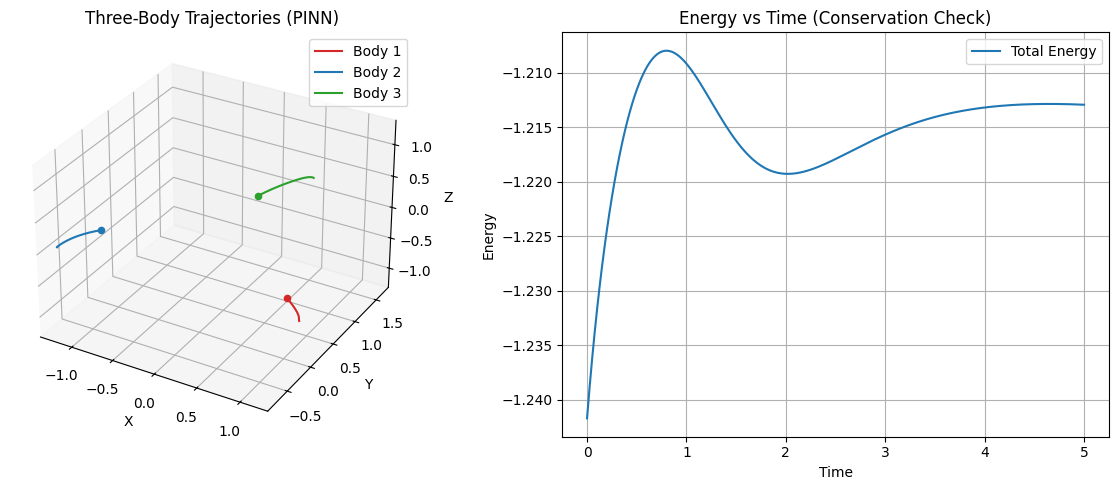

In [ ]:
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 3D 플롯용

# =======================
# 1. 모델 평가용 샘플링 함수
# =======================
def evaluate_model(model, t_max, num_steps=400):
    t = torch.linspace(0.0, t_max, num_steps, device=device).view(-1, 1)
    t.requires_grad_(True)
    pos, vel, acc = time_derivatives(model, t)
    R = pos.view(-1, 3, 3)
    V = vel.view(-1, 3, 3)
    E = total_energy(R, V, masses, G=G)

    t_np = t.squeeze(1).cpu().detach().numpy()
    R_np = R.cpu().cpu().detach().numpy()
    E_np = E.cpu().cpu().detach().numpy()
    return t_np, R_np, E_np



# =======================
# 2. 시각화 함수
# =======================
def plot_trajectory_and_energy(t_np, R_np, E_np):
    """
    t_np:  (N,)
    R_np:  (N,3,3)
    E_np:  (N,)
    """

    fig = plt.figure(figsize=(12, 5))

    # ----- (a) 3D 궤적 플롯 -----
    ax3d = fig.add_subplot(1, 2, 1, projection='3d')

    colors = ['tab:red', 'tab:blue', 'tab:green']
    labels = ['Body 1', 'Body 2', 'Body 3']

    for i in range(3):
        xi = R_np[:, i, 0]
        yi = R_np[:, i, 1]
        zi = R_np[:, i, 2]

        ax3d.plot(xi, yi, zi, color=colors[i], label=labels[i])
        ax3d.scatter(xi[0], yi[0], zi[0], color=colors[i], marker='o')  # 시작점

    ax3d.set_xlabel('X')
    ax3d.set_ylabel('Y')
    ax3d.set_zlabel('Z')
    ax3d.set_title('Three-Body Trajectories (PINN)')
    ax3d.legend()
    ax3d.grid(True)

    # 축 비율 동일하게 맞추기 (3D에서 중요)
    x_all = R_np[:, :, 0].flatten()
    y_all = R_np[:, :, 1].flatten()
    z_all = R_np[:, :, 2].flatten()
    max_range = max(
        x_all.max() - x_all.min(),
        y_all.max() - y_all.min(),
        z_all.max() - z_all.min()
    ) / 2.0

    mid_x = 0.5 * (x_all.max() + x_all.min())
    mid_y = 0.5 * (y_all.max() + y_all.min())
    mid_z = 0.5 * (z_all.max() + z_all.min())

    ax3d.set_xlim(mid_x - max_range, mid_x + max_range)
    ax3d.set_ylim(mid_y - max_range, mid_y + max_range)
    ax3d.set_zlim(mid_z - max_range, mid_z + max_range)

    # ----- (b) 에너지 vs 시간 -----
    axE = fig.add_subplot(1, 2, 2)
    axE.plot(t_np, E_np, label='Total Energy')
    axE.set_xlabel('Time')
    axE.set_ylabel('Energy')
    axE.set_title('Energy vs Time (Conservation Check)')
    axE.grid(True)
    axE.legend()

    plt.tight_layout()
    plt.show()


# =======================
# 3. 실제로 평가 + 플롯 실행
# =======================
# (학습이 끝난 model이 있다고 가정: model.load_state_dict(...) 했거나 방금 학습 완료 상태)

t_np, R_np, E_np = evaluate_model(model, 5.0, num_steps=400)
plot_trajectory_and_energy(t_np, R_np, E_np)


In [ ]:
import numpy as np

E0 = E_np[0]
rel_error = np.abs(E_np - E0) / np.abs(E0)

print("max relative energy error:", rel_error.max())
print("mean relative energy error:", rel_error.mean())


max relative energy error: 0.2527759
mean relative energy error: 0.19923604
